# Lecture 10 (B09): Physics-informed neural networks

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §7.1-7.4 (PINN foundations), §7.5-7.9 (Economic PDEs (HJB, Black-Scholes))  
**Notebook role:** core  
**Original live-course source:** `lectures/day6/code/05_Black_Scholes_PINN.ipynb`  
**Course author:** Simon Scheidegger  
**License:** see repository `LICENSE` (MIT, code) and `LICENSE-content.md` (CC0 1.0, content).


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Solving the Black-Scholes PDE with Physics-Informed Neural Networks

*Companion notebook to **Day 6 — PINNs and Continuous-Time Heterogeneous Agents** (Chapters 7–8 of the lecture script).*

*Author: Simon Scheidegger (HEC Lausanne and Grantham Institute, LSE) — [course repository](https://github.com/sischei/Deep_Learning_for_Solving_And_Estimating_Dynamic_Economic_Models).*

This notebook demonstrates how to solve the **Black-Scholes partial differential equation** for European call option pricing using a **Physics-Informed Neural Network (PINN)**.

## Relevance to Central Banking

Option pricing models are a cornerstone of modern financial risk management. Central banks routinely monitor option-implied measures — such as implied volatilities, risk-neutral densities, and the Greeks — to assess market expectations and gauge financial stability. The Black-Scholes model, while stylized, provides the canonical framework on which more realistic models are built.

PINNs offer a mesh-free, differentiable alternative to traditional finite-difference solvers for pricing PDEs. Because PINNs leverage automatic differentiation, they yield the option price **and** its sensitivities (the Greeks) simultaneously, without any additional numerical effort. This makes them attractive for stress-testing and scenario analysis in supervisory contexts.

## The Black-Scholes PDE

For a European call option with value $V(S,t)$, the PDE reads:

$$\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + r S \frac{\partial V}{\partial S} - r V = 0,$$

subject to:
- **Terminal condition:** $V(S, T) = \max(S - K, 0)$
- **Boundary at $S=0$:** $V(0, t) = 0$
- **Boundary at $S=S_{\max}$:** $V(S_{\max}, t) = S_{\max} - K e^{-r(T-t)}$

> **Self-study notebook** \u2014 This notebook complements the in-class PINNs session (Day 6, Block 1). Work through it at your own pace.

In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams['font.size'] = 13

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)
torch.set_default_dtype(torch.float64)

# torch.compile is not used in this notebook. The residual contains nested
# autograd calls, and the deterministic L-BFGS polish is easier to inspect in
# plain eager mode.


In [2]:

# ── Device setup ──────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
print(f"Using device: {device} | dtype: {dtype}")

# ── Black-Scholes parameters ─────────────────────────────────────────
r     = 0.05    # risk-free rate
sigma = 0.2     # volatility
K     = 50.0    # strike price
T     = 1.0     # maturity (years)
S_max = 100.0   # upper bound on spot price domain


Using device: cpu | dtype: torch.float64


## PINN Architecture

The network takes a two-dimensional input $(S, t)$ and outputs the option value $V(S, t)$.
We use a fully connected feed-forward network with three hidden layers of 50 neurons each
and $\tanh$ activation functions (smooth activations are important because the PDE loss
requires second-order derivatives).

In [3]:

class PINN(nn.Module):
    """Physics-Informed Neural Network for the Black-Scholes PDE.

    Inputs are normalised to [-1, 1] and the output is scaled by the strike.
    This makes the PDE, terminal, and boundary losses numerically comparable.
    """

    def __init__(self, layer_sizes=None, S_max=S_max, T=T, price_scale=K):
        super().__init__()
        if layer_sizes is None:
            layer_sizes = [2, 64, 64, 64, 1]
        self.S_max = float(S_max)
        self.T = float(T)
        self.price_scale = float(price_scale)

        layers = []
        for i in range(len(layer_sizes) - 2):
            layers += [nn.Linear(layer_sizes[i], layer_sizes[i + 1]), nn.Tanh()]
        layers += [nn.Linear(layer_sizes[-2], layer_sizes[-1])]
        self.net = nn.Sequential(*layers)

    def forward(self, S, t):
        S_n = 2.0 * S / self.S_max - 1.0
        t_n = 2.0 * t / self.T - 1.0
        return self.price_scale * self.net(torch.cat([S_n, t_n], dim=1))


model = PINN().to(device=device, dtype=dtype)
print(model)


PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


## PDE Residual via Automatic Differentiation

The key idea behind PINNs is to enforce the PDE in its strong form at a set of
collocation points. We compute the required partial derivatives $V_t$, $V_S$,
and $V_{SS}$ using PyTorch's automatic differentiation engine (`torch.autograd.grad`).
The PDE residual should be driven to zero during training.

In [4]:

def pde_residual(model, S, t):
    """
    Compute the Black-Scholes PDE residual:
        R = V_t + 0.5*sigma^2*S^2*V_SS + r*S*V_S - r*V
    """
    S = S.clone().detach().requires_grad_(True)
    t = t.clone().detach().requires_grad_(True)

    V = model(S, t)
    V_t = torch.autograd.grad(
        V, t, grad_outputs=torch.ones_like(V),
        create_graph=True, retain_graph=True
    )[0]
    V_S = torch.autograd.grad(
        V, S, grad_outputs=torch.ones_like(V),
        create_graph=True, retain_graph=True
    )[0]
    V_SS = torch.autograd.grad(
        V_S, S, grad_outputs=torch.ones_like(V_S),
        create_graph=True, retain_graph=True
    )[0]

    residual = V_t + 0.5 * sigma**2 * S**2 * V_SS + r * S * V_S - r * V
    return residual


## Sampling Collocation Points

We draw random collocation points in the interior of the domain
$[0, S_{\max}] \times [0, T]$ as well as on each boundary (the terminal condition,
the $S=0$ boundary, and the $S=S_{\max}$ boundary). Points are resampled every
epoch so the network does not overfit to a fixed grid.

In [5]:

def sampler(n_interior, n_bc, n_terminal, n_bc_Smax):
    """Sample collocation, boundary, and terminal points."""
    S_int = torch.rand(n_interior, 1, device=device, dtype=dtype) * S_max
    t_int = torch.rand(n_interior, 1, device=device, dtype=dtype) * T

    S_bc0 = torch.zeros(n_bc, 1, device=device, dtype=dtype)
    t_bc0 = torch.rand(n_bc, 1, device=device, dtype=dtype) * T

    S_term = torch.rand(n_terminal, 1, device=device, dtype=dtype) * S_max
    t_term = torch.ones(n_terminal, 1, device=device, dtype=dtype) * T

    S_bcmax = torch.ones(n_bc_Smax, 1, device=device, dtype=dtype) * S_max
    t_bcmax = torch.rand(n_bc_Smax, 1, device=device, dtype=dtype) * T

    return (S_int, t_int, S_bc0, t_bc0, S_term, t_term, S_bcmax, t_bcmax)



## Training the PINN

The loss terms are divided by the strike so that a boundary error of one currency unit does not overwhelm the scaled PDE residual. We use Adam to reach the right basin and then run L-BFGS on a fixed double-precision training batch. This is the stage where double precision is especially useful, because L-BFGS line-search and stopping criteria are sensitive to small loss changes.

In [6]:

adam_lr = 1e-3
n_epochs = 2_500
n_interior = 1_000
n_bc = 256
n_terminal = 512
n_bc_Smax = 256
terminal_weight = 10.0

optimizer = optim.Adam(model.parameters(), lr=adam_lr)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[1_200, 2_000], gamma=0.4)
loss_history = []


def loss_terms(batch):
    S_int_, t_int_, S_bc0_, t_bc0_, S_term_, t_term_, S_bcmax_, t_bcmax_ = batch

    res = pde_residual(model, S_int_, t_int_) / K
    mse_pde = torch.mean(res ** 2)

    V_bc0 = model(S_bc0_, t_bc0_) / K
    mse_bc0 = torch.mean(V_bc0 ** 2)

    V_term = model(S_term_, t_term_) / K
    payoff = torch.relu(S_term_ - K) / K
    mse_terminal = torch.mean((V_term - payoff) ** 2)

    V_bcmax = model(S_bcmax_, t_bcmax_) / K
    V_bcmax_exact = (S_max - K * torch.exp(-r * (T - t_bcmax_))) / K
    mse_bcmax = torch.mean((V_bcmax - V_bcmax_exact) ** 2)

    loss = mse_pde + mse_bc0 + terminal_weight * mse_terminal + mse_bcmax
    return loss, mse_pde, mse_bc0, mse_terminal, mse_bcmax


for epoch in range(1, n_epochs + 1):
    batch = sampler(n_interior, n_bc, n_terminal, n_bc_Smax)
    optimizer.zero_grad()
    loss, mse_pde, mse_bc0, mse_terminal, mse_bcmax = loss_terms(batch)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 50.0)
    optimizer.step()
    scheduler.step()
    loss_history.append(loss.item())

    if epoch % 500 == 0 or epoch == 1:
        print(
            f"Adam {epoch:>5d}/{n_epochs}  "
            f"Loss: {loss.item():.4e}  "
            f"(PDE: {mse_pde.item():.3e}, "
            f"BC0: {mse_bc0.item():.3e}, "
            f"Term: {mse_terminal.item():.3e}, "
            f"BCmax: {mse_bcmax.item():.3e})"
        )

# Deterministic FP64 L-BFGS polish on one fixed design.
lbfgs_batch = sampler(2_048, 512, 1_024, 512)
lbfgs = optim.LBFGS(
    model.parameters(),
    max_iter=300,
    tolerance_grad=1e-12,
    tolerance_change=1e-14,
    line_search_fn="strong_wolfe",
)
lbfgs_evals = [0]


def lbfgs_closure():
    lbfgs.zero_grad()
    loss, mse_pde, mse_bc0, mse_terminal, mse_bcmax = loss_terms(lbfgs_batch)
    loss.backward()
    lbfgs_evals[0] += 1
    if lbfgs_evals[0] == 1 or lbfgs_evals[0] % 50 == 0:
        print(
            f"L-BFGS eval {lbfgs_evals[0]:>4d} | loss={loss.item():.3e} "
            f"(pde={mse_pde.item():.1e}, term={mse_terminal.item():.1e})"
        )
    return loss

lbfgs.step(lbfgs_closure)
print(f"Final deterministic training loss: {lbfgs_closure().item():.3e}")


Adam     1/2500  Loss: 2.0475e+00  (PDE: 4.748e-03, BC0: 1.182e-02, Term: 1.285e-01, BCmax: 7.456e-01)


Adam   500/2500  Loss: 4.8266e-03  (PDE: 1.213e-03, BC0: 2.495e-04, Term: 3.107e-04, BCmax: 2.571e-04)


Adam  1000/2500  Loss: 8.0787e-04  (PDE: 2.944e-04, BC0: 7.731e-06, Term: 4.937e-05, BCmax: 1.208e-05)


Adam  1500/2500  Loss: 5.7067e-04  (PDE: 2.107e-04, BC0: 4.897e-06, Term: 3.444e-05, BCmax: 1.071e-05)


Adam  2000/2500  Loss: 5.8058e-04  (PDE: 1.666e-04, BC0: 1.470e-05, Term: 3.806e-05, BCmax: 1.876e-05)


...

L-BFGS eval  150 | loss=1.317e-04 (pde=4.2e-05, term=8.5e-06)


L-BFGS eval  200 | loss=1.022e-04 (pde=3.6e-05, term=6.5e-06)


L-BFGS eval  250 | loss=8.474e-05 (pde=3.8e-05, term=4.5e-06)


L-BFGS eval  300 | loss=7.404e-05 (pde=2.9e-05, term=4.4e-06)


Final deterministic training loss: 7.050e-05


## Analytical Black-Scholes Formula

For validation we compare the PINN solution against the closed-form Black-Scholes
formula for a European call:

$$C(S, t) = S\,\Phi(d_1) - K e^{-r(T-t)}\Phi(d_2),$$

where $d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)(T-t)}{\sigma\sqrt{T-t}}$ and $d_2 = d_1 - \sigma\sqrt{T-t}$.

In [7]:
def black_scholes_call(S, K, T_minus_t, r, sigma):
    """
    Analytical Black-Scholes price for a European call.

    Parameters
    ----------
    S          : array-like, spot price
    K          : float, strike
    T_minus_t  : float, time to maturity
    r          : float, risk-free rate
    sigma      : float, volatility

    Returns
    -------
    C : np.ndarray, call prices
    """
    S = np.asarray(S, dtype=np.float64)
    # Handle S = 0 gracefully
    C = np.zeros_like(S)
    mask = S > 0
    d1 = (np.log(S[mask] / K) + (r + 0.5 * sigma**2) * T_minus_t) / (
        sigma * np.sqrt(T_minus_t)
    )
    d2 = d1 - sigma * np.sqrt(T_minus_t)
    C[mask] = S[mask] * norm.cdf(d1) - K * np.exp(-r * T_minus_t) * norm.cdf(d2)
    return C

## Comparison: PINN vs. Analytical Solution

We evaluate both the trained PINN and the analytical formula at $t = 0$
(i.e. time to maturity $= T$) across the full range of spot prices.

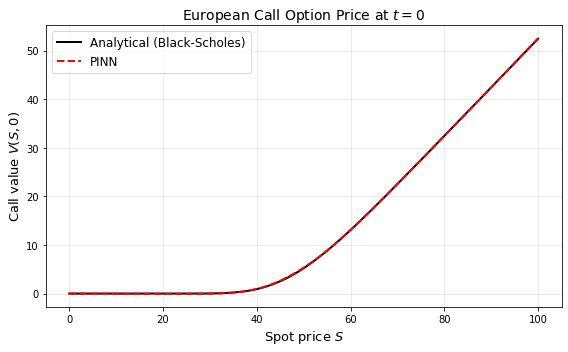

In [8]:

# Evaluate at t = 0
S_test_np = np.linspace(0, S_max, 200)
S_test = torch.tensor(S_test_np, dtype=dtype, device=device).reshape(-1, 1)
t_test = torch.zeros_like(S_test)

model.eval()
with torch.no_grad():
    V_pinn = model(S_test, t_test).cpu().numpy().flatten()

V_exact = black_scholes_call(S_test_np, K, T, r, sigma)

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(S_test_np, V_exact, "k-", linewidth=2, label="Analytical (Black-Scholes)")
ax.plot(S_test_np, V_pinn, "r--", linewidth=2, label="PINN")
ax.set_xlabel(r"Spot price $S$", fontsize=13)
ax.set_ylabel("Call value $V(S, 0)$", fontsize=13)
ax.set_title(r"European Call Option Price at $t = 0$", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Error Analysis

We quantify the point-wise absolute error $|V_{\text{PINN}}(S,0) - V_{\text{exact}}(S,0)|$
across the spot-price domain.

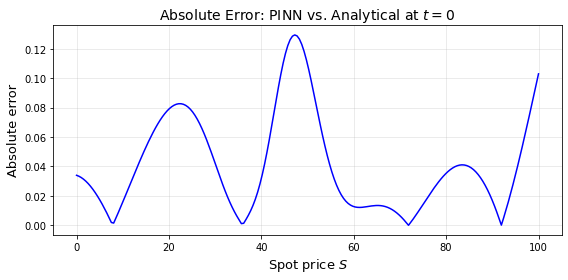

Max  absolute error: 0.129431
Mean absolute error: 0.040726


In [9]:
abs_error = np.abs(V_pinn - V_exact)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(S_test_np, abs_error, "b-", linewidth=1.5)
ax.set_xlabel(r"Spot price $S$", fontsize=13)
ax.set_ylabel("Absolute error", fontsize=13)
ax.set_title(r"Absolute Error: PINN vs. Analytical at $t = 0$", fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Max  absolute error: {np.max(abs_error):.6f}")
print(f"Mean absolute error: {np.mean(abs_error):.6f}")

## Discussion: The Greeks

A powerful advantage of the PINN approach is that the **Greeks** — the price
sensitivities with respect to the underlying parameters — are available
essentially for free via automatic differentiation:

| Greek   | Definition          | Interpretation                       |
|---------|---------------------|--------------------------------------|
| Delta   | $\Delta = V_S$     | Sensitivity to spot price            |
| Gamma   | $\Gamma = V_{SS}$  | Convexity with respect to spot price |
| Theta   | $\Theta = V_t$     | Sensitivity to passage of time       |

There is no need for finite-difference bumping or re-solving the PDE.
Below we illustrate this by computing **Delta** at $t = 0$.

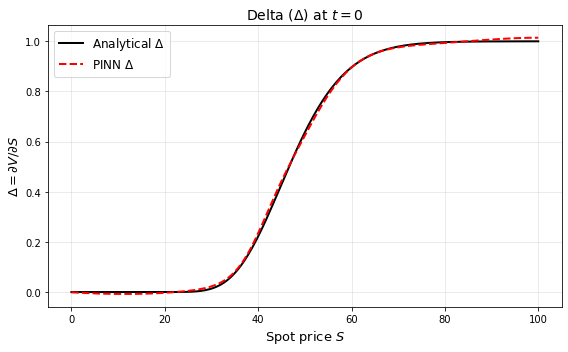

In [10]:

# Compute Delta = dV/dS at t = 0 via automatic differentiation
S_greek = torch.tensor(
    S_test_np, dtype=dtype, device=device
).reshape(-1, 1).requires_grad_(True)
t_greek = torch.zeros_like(S_greek)

V_greek = model(S_greek, t_greek)

delta = torch.autograd.grad(
    V_greek, S_greek,
    grad_outputs=torch.ones_like(V_greek),
    create_graph=False
)[0]

delta_np = delta.detach().cpu().numpy().flatten()

# Analytical Delta for comparison
mask = S_test_np > 0
delta_exact = np.zeros_like(S_test_np)
d1 = (np.log(S_test_np[mask] / K) + (r + 0.5 * sigma**2) * T) / (
    sigma * np.sqrt(T)
)
delta_exact[mask] = norm.cdf(d1)

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(S_test_np, delta_exact, "k-", linewidth=2, label=r"Analytical $\Delta$")
ax.plot(S_test_np, delta_np, "r--", linewidth=2, label=r"PINN $\Delta$")
ax.set_xlabel(r"Spot price $S$", fontsize=13)
ax.set_ylabel(r"$\Delta = \partial V / \partial S$", fontsize=13)
ax.set_title(r"Delta ($\Delta$) at $t = 0$", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
